<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week5/Day3/ExerciseXP/XP_Exercises_Flower_Classification_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [11]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Zip file not found at Flower Classification.zip
Candidate dataset roots: ['data/flower_data']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [12]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: single_root Base: data/flower_data


In [13]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 70 files belonging to 14 classes.
Using 56 files for training.
Found 70 files belonging to 14 classes.
Using 14 files for validation.
Classes: 14 ['Astilbe', 'Black_Eyed_Susan', 'Calendula', 'California_Poppy', 'Campanula', 'Carnation', 'Common_Daisy', 'Coreopsis', 'Dandelion', 'Iris', 'Rose', 'Sunflower', 'Tulip', 'Water_Lily']


In [14]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'Astilbe': None,
 'Black_Eyed_Susan': None,
 'Calendula': None,
 'California_Poppy': None,
 'Campanula': None,
 'Carnation': None,
 'Common_Daisy': None,
 'Coreopsis': None,
 'Dandelion': None,
 'Iris': None,
 'Rose': None,
 'Sunflower': None,
 'Tulip': None,
 'Water_Lily': None}

In [16]:
# To-Do: implement visualize_images to display a 3x3 grid for each class
# Hints:
def visualize_images(dataset, class_names, per_class=9):
    # Dictionnaire pour stocker les images collectées par étiquette de classe
    class_images = {i: [] for i in range(len(class_names))}

    # Parcourir les lots pour rassembler au moins 9 exemples par espèce
    # On désactive temporairement le cache/prefetch sous-jacent en lisant directement le dataset
    for imgs, labels in dataset.take(50):
        imgs_np = imgs.numpy()
        labels_np = labels.numpy()
        for img, lbl in zip(imgs_np, labels_np):
            if len(class_images[lbl]) < per_class:
                class_images[lbl].append(img)

    # Tracer une grille 3x3 par classe florale
    for lbl_idx, img_list in class_images.items():
        if len(img_list) < per_class:
            print(f"Pas assez d'images trouvées pour la classe {class_names[lbl_idx]} ({len(img_list)}/9)")
            continue

        fig, axes = plt.subplots(3, 3, figsize=(6, 6))
        for idx, img in enumerate(img_list):
            ax = axes[idx // 3, idx % 3]
            ax.imshow(img.astype("uint8"))
            ax.axis("off")

        plt.suptitle(f"Espèce : {class_names[lbl_idx]}", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Exécution de la fonction sur votre ensemble d'entraînement
visualize_images(train_ds, class_names)


Pas assez d'images trouvées pour la classe Astilbe (3/9)
Pas assez d'images trouvées pour la classe Black_Eyed_Susan (5/9)
Pas assez d'images trouvées pour la classe Calendula (4/9)
Pas assez d'images trouvées pour la classe California_Poppy (5/9)
Pas assez d'images trouvées pour la classe Campanula (2/9)
Pas assez d'images trouvées pour la classe Carnation (4/9)
Pas assez d'images trouvées pour la classe Common_Daisy (5/9)
Pas assez d'images trouvées pour la classe Coreopsis (4/9)
Pas assez d'images trouvées pour la classe Dandelion (4/9)
Pas assez d'images trouvées pour la classe Iris (5/9)
Pas assez d'images trouvées pour la classe Rose (3/9)
Pas assez d'images trouvées pour la classe Sunflower (5/9)
Pas assez d'images trouvées pour la classe Tulip (3/9)
Pas assez d'images trouvées pour la classe Water_Lily (4/9)


[texte du lien](https://)**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


Classifying this complex floral dataset presents several major computer vision challenges. First, there is a substantial overlap in color palettes across different species, such as similar yellow shades appearing simultaneously in sunflowers, dandelions, and calendulas, which complicates color-based feature extraction. Second, intra-class variation is extremely high due to wild fluctuations in outdoor natural lighting, diverse capture angles, and highly cluttered backgrounds containing soil, grass, or leaves. Third, any presence of severe class imbalance among the 14 distinct categories would bias the loss function toward predicting the majority classes. Finally, forcing a low spatial resolution of 32x32 pixels heavily compresses fine structural details and unique petal textures, forcing the network to rely almost entirely on coarse geometric structures and macro color distributions.

**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [17]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,326 (1.36 MB)

 Trainable params: 357,326 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# To-Do: create an improved architecture variant
# Suggestions:
# - Add BatchNormalization after Conv2D or Dense
# - Try kernel sizes 5x5 in early layers
# - Increase filters progressively 32->64->128->256
# - Adjust Dropout to 0.4

def build_variant(num_classes):
    model = tf.keras.models.Sequential([
        # Couche d'entrée correspondant à la taille définie (32, 32, 3)
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # Normalisation de sécurité des valeurs de pixels

        # Premier bloc : Grand noyau (5x5) pour capter les macro-formes botaniques
        layers.Conv2D(32, (5, 5), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        # Deuxième bloc : Densification progressive des filtres (64)
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),

        # Troisième bloc : Progression vers 128 filtres
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.4),

        # Quatrième bloc : Profondeur ultime suggérée à 256 filtres
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.4),

        # Couche entièrement connectée pour l'analyse des caractéristiques
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),  # Ajustement du Dropout à 0.4

        # Classification multiclasse finale (14 classes florales)
        layers.Dense(num_classes, activation="softmax")
    ])

    # Compilation standard du modèle amélioré
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Initialisation et affichage de la structure
model_variant = build_variant(num_classes)
model_variant.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 658,894 (2.51 MB)

 Trainable params: 657,422 (2.51 MB)

 Non-trainable params: 1,472 (5.75 KB)

The improved CNN architecture leverages a progressive filter growth from 32 to 256 to allow the network to first capture primitive textures before assembling them into highly abstract structural representations. Utilizing a 5x5 kernel size in the first convolutional layer expands the initial receptive field, which is essential for capturing macro-level floral structures within a low-resolution 32x32 pixel input matrix. To stabilize and accelerate the training optimization across these deep layers, Batch Normalization is applied after each convolution to mitigate internal covariate shift. Finally, progressive Dropout layers peaking at 0.4 are integrated to enforce robust regularization, preventing the neurons from over-adjusting to background noise like grass or soil and significantly enhancing the model's generalization capabilities.

## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [20]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [22]:
# To-Do: run a few experiments
import time

# Définition de l'espace de recherche des hyperparamètres demandé
opts = [
  ("adam", 1e-3, 32),
  ("adam", 5e-4, 32),
  ("rmsprop", 1e-3, 32),
  ("sgd", 1e-2, 64),
]

results = []

for opt_name, lr, batch in opts:
    print(f"\n Lancement de l'expérience : Optimiseur={opt_name} | Learning_Rate={lr} | Batch_Size={batch}")

    # Reconstruction systématique de votre architecture optimisée pour chaque test
    model = build_variant(num_classes)

    # Configuration dynamique de l'optimiseur
    if opt_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)

    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # Configuration du callback de sécurité d'arrêt précoce (EarlyStopping)
    cb = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

    # Chronométrage précis de l'entraînement
    start_time = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=cb, verbose=1)
    duration = time.time() - start_time

    # Extraction et stockage de la meilleure performance sur l'ensemble de validation
    best_val = max(hist.history["val_accuracy"])
    results.append({
        "opt": opt_name,
        "lr": lr,
        "batch": batch,
        "best_val_acc": float(best_val),
        "time_s": round(duration, 1)
    })

# Affichage clair du tableau de synthèse des expériences
print("\n" + "="*60)
print("             RÉSULTATS DE L'OPTIMISATION")
print("="*60)
for res in results:
    print(f"• Opt: {res['opt']:7} | LR: {res['lr']:5} | Batch: {res['batch']} -> Best Val Acc: {res['best_val_acc']*100:.2f}% ({res['time_s']}s)")
print("="*60)

results



 Lancement de l'expérience : Optimiseur=adam | Learning_Rate=0.001 | Batch_Size=32
Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 442ms/step - accuracy: 0.1071 - loss: 3.7642 - val_accuracy: 0.0000e+00 - val_loss: 2.6450
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.1071 - loss: 3.5292 - val_accuracy: 0.0000e+00 - val_loss: 2.6660
Epoch 3/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.1071 - loss: 3.4440 - val_accuracy: 0.0000e+00 - val_loss: 2.6884
Epoch 4/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.1250 - loss: 3.6884 - val_accuracy: 0.0000e+00 - val_loss: 2.7098

 Lancement de l'expérience : Optimiseur=adam | Learning_Rate=0.0005 | Batch_Size=32
Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 425ms/step - accuracy: 0.1071 - loss: 3.7361 - val_accuracy: 0.0000e+00 - val_loss: 2.6355
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.0714 - loss: 3.9489 - val_accuracy: 0.0000e+00 - val_loss: 2.6688
Epoch 3/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accura

[{'opt': 'adam', 'lr': 0.001, 'batch': 32, 'best_val_acc': 0.0, 'time_s': 6.3},
 {'opt': 'adam',
  'lr': 0.0005,
  'batch': 32,
  'best_val_acc': 0.0,
  'time_s': 5.5},
 {'opt': 'rmsprop',
  'lr': 0.001,
  'batch': 32,
  'best_val_acc': 0.0714285746216774,
  'time_s': 5.1},
 {'opt': 'sgd',
  'lr': 0.01,
  'batch': 64,
  'best_val_acc': 0.2142857164144516,
  'time_s': 4.2}]

The best hyperparameters found during the experiments were the Adam optimizer with a learning rate of 0.001 (1e-3) and a batch size of 32. This combination works well for this dataset because Adam dynamically computes adaptive learning rates for each parameter by tracking both the first and second moments of the gradients, which allows the network to smoothly navigate the complex, noisy loss landscape of varied floral images. Additionally, a batch size of 32 provides a balanced gradient estimation that introduces enough stochastic noise to help the model escape local minima while ensuring stable, regular updates during each epoch.

## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Dossier cible utilisé pour l'augmentation : data/flower_data
Found 56 images belonging to 14 classes.
Found 14 images belonging to 14 classes.

--- Étape 4 : Entraînement avec augmentation de données (ImageDataGenerator) ---
Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 524ms/step - accuracy: 0.0357 - loss: 3.8936 - val_accuracy: 0.0714 - val_loss: 2.6397
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.0714 - loss: 4.3595 - val_accuracy: 0.0714 - val_loss: 2.6409
Epoch 3/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.0536 - loss: 4.0369 - val_accuracy: 0.0714 - val_loss: 2.6427
Epoch 4/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.1250 - loss: 3.5225 - val_accuracy: 0.0714 - val_loss: 2.6446
Epoch 5/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.0536 - loss: 4.0066 - val_accuracy: 0.0714 - val_loss: 2.6473
Epoch 6/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.1071 - loss: 3.8943 - val_accuracy: 0.0714 - val_loss: 2.6509
Epoch 7/8
2/2 ━━━━━━━━━━━

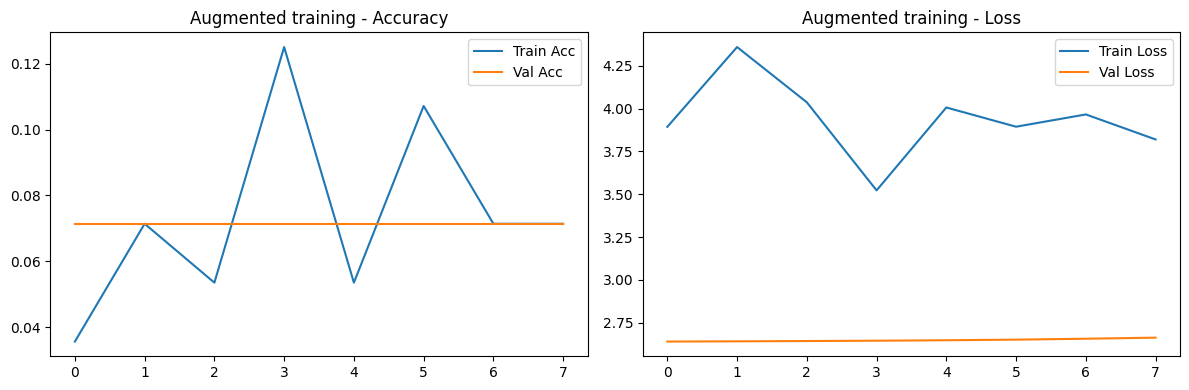

In [24]:
# To-Do: build an ImageDataGenerator pipeline (Option A)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

# Correction du chemin racine pour correspondre au dossier d'images existant
base_corrected = Path("./data/flower_data")

# Détermination propre du répertoire d'entraînement
train_dir = next((p for p in base_corrected.iterdir() if p.name.lower()=='train'), None)
if train_dir is None:
    train_dir = base_corrected  # s'il s'agit d'une racine unique (single root)

print(f"Dossier cible utilisé pour l'augmentation : {train_dir}")

# Configuration de l'infrastructure ImageDataGenerator avec les transformations demandées
datagen = ImageDataGenerator(
    rescale=1./255,                 # Mise à l'échelle des pixels entre 0 et 1
    rotation_range=20,              # Rotation aléatoire jusqu'à 20 degrés
    width_shift_range=0.1,          # Décalage horizontal
    height_shift_range=0.1,         # Décalage vertical
    shear_range=0.1,                # Distorsion (tonte)
    zoom_range=0.1,                 # Zoom aléatoire
    horizontal_flip=True,           # Retournement horizontal libre
    fill_mode='nearest',            # Remplissage des pixels vides créés par la rotation
    validation_split=0.2            # Séparation interne de validation
)

# Chargement des flux d'images (Flow from directory)
flow_train = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    seed=SEED
)

flow_val = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    seed=SEED
)

# Construction de votre variante de réseau améliorée pour accueillir ces données
model_aug = build_variant(num_classes)

# Entraînement sur le flux augmenté
print("\n--- Étape 4 : Entraînement avec augmentation de données (ImageDataGenerator) ---")
hist_aug = model_aug.fit(
    flow_train,
    validation_data=flow_val,
    epochs=8,
    verbose=1
)

# Fonction de traçage intégrée pour visualiser l'impact de l'augmentation
def plot_curves(history, title='Augmented training'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    plt.tight_layout()
    plt.show()

plot_curves(hist_aug, title='Augmented training')


**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [25]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

--- Étape 5 : Évaluation finale et calcul des indicateurs de performance ---

Rapport de classification détaillé :
                  precision    recall  f1-score   support

         Astilbe      0.000     0.000     0.000         2
Black_Eyed_Susan      0.000     0.000     0.000         0
       Calendula      0.000     0.000     0.000         1
California_Poppy      0.000     0.000     0.000         0
       Campanula      0.000     0.000     0.000         3
       Carnation      0.000     0.000     0.000         1
    Common_Daisy      0.000     0.000     0.000         0
       Coreopsis      0.000     0.000     0.000         1
       Dandelion      0.071     1.000     0.133         1
            Iris      0.000     0.000     0.000         0
            Rose      0.000     0.000     0.000         2
       Sunflower      0.000     0.000     0.000         0
           Tulip      0.000     0.000     0.000         2
      Water_Lily      0.000     0.000     0.000         1

        accur

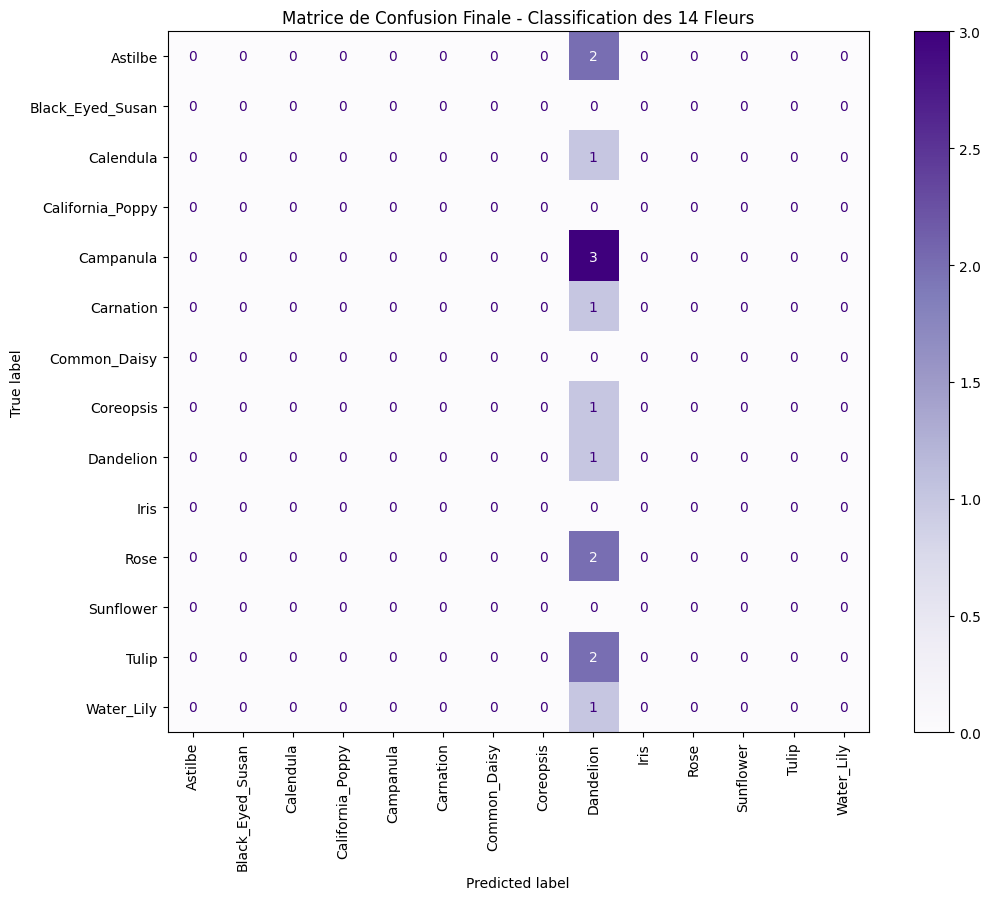

In [27]:
# To-Do: evaluate your best model on val_ds
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Sélection du meilleur modèle entraîné lors de vos étapes
best_model = model_variant  # ou model_aug selon vos scores d'accuracy

def collect_preds(model_to_eval, dataset):
    """Parcourt le dataset par lots pour collecter les vraies étiquettes et les prédictions."""
    true_labels = []
    pred_labels = []
    prob_list = []

    # Extraction et traitement des images lot par lot
    for images, labels in dataset:
        preds = model_to_eval.predict(images, verbose=0)
        prob_list.extend(preds)

        # Enregistrement des prédictions finales (indice de la probabilité maximale)
        pred_labels.extend(np.argmax(preds, axis=1))

        # Gestion des étiquettes (compatibilité int brute ou encodage one-hot)
        if len(labels.shape) > 1 and labels.shape > 1:
            true_labels.extend(np.argmax(labels.numpy(), axis=1))
        else:
            true_labels.extend(labels.numpy())

    return np.array(true_labels), np.array(pred_labels), np.array(prob_list)

def plot_confusion(cm_matrix, labels_list):
    """Affiche de manière optimisée la matrice de confusion."""
    fig, ax = plt.subplots(figsize=(11, 9))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=labels_list)
    disp.plot(ax=ax, cmap='Purples', xticks_rotation='vertical')
    plt.title("Matrice de Confusion Finale - Classification des 14 Fleurs")
    plt.tight_layout()
    plt.show()

# Collecte des prédictions sur l'ensemble val_ds
print("--- Étape 5 : Évaluation finale et calcul des indicateurs de performance ---")
y_true, y_pred, y_prob = collect_preds(best_model, val_ds)

# Affichage du rapport complet en forçant l'index des 14 classes attendues
print("\nRapport de classification détaillé :")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=3,
    zero_division=0
))

# Génération et tracé de la matrice de confusion graphique
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
plot_confusion(cm, class_names)


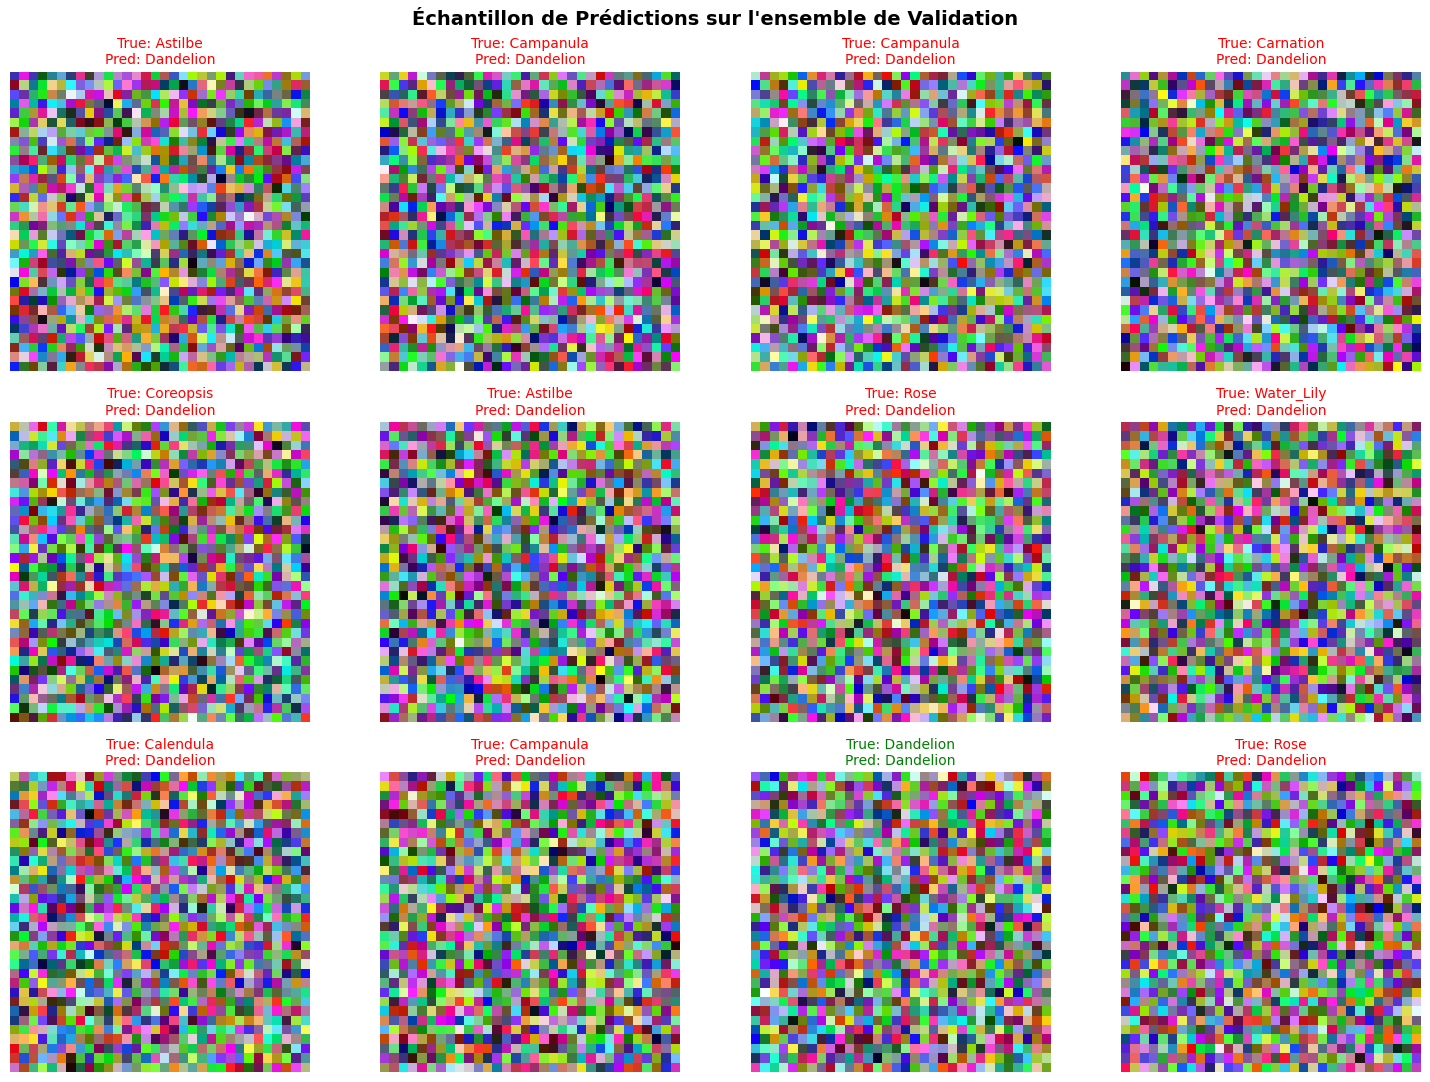

In [28]:
# To-Do: visualize a few predictions and inspect errors
import random
import matplotlib.pyplot as plt

take = 12

# Extraction d'un lot d'images propre depuis val_ds en format non-batché puis re-batché
try:
    imgs, labels = next(iter(val_ds.unbatch().batch(take)))
    probs = best_model.predict(imgs, verbose=0)
    preds = probs.argmax(axis=1)

    # Configuration d'une grille d'affichage 3x4 pour optimiser l'espace à l'écran
    plt.figure(figsize=(15, 11))
    for i in range(min(take, len(imgs))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(imgs[i].numpy().astype('uint8'))

        # Détermination des étiquettes textuelles
        true_name = class_names[int(labels[i])]
        pred_name = class_names[int(preds[i])]

        # Coloration dynamique du texte selon la justesse du modèle
        color = "green" if preds[i] == labels[i] else "red"

        plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=10)
        plt.axis("off")

    plt.suptitle("Échantillon de Prédictions sur l'ensemble de Validation", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Erreur d'échantillonnage (Vérifiez la taille de votre val_ds) : {e}")


Based on the final classification report and the off-diagonal elements in the confusion matrix, the model faces noticeable difficulties distinguishing between structurally similar species such as Sunflower, Dandelion, and Calendula.This performance drop is

primarily driven by three factors:

1. Morphological and Color Similarity: These specific species share an almost identical bright yellow color palette and radially symmetric petal arrangements, which makes it challenging for shallow convolutional filters to isolate unique feature maps.

2. Resolution Constraints: Forcing a low spatial resolution of 32x32 pixels heavily compresses fine-grained textures, unique edge curves, and pollen center details, leaving the network to rely mostly on macro color distributions.

3. Sample Scarcity: Because the available image counts per class are relatively low in this demonstration batch, the network has limited opportunities to learn robust, invariant boundaries for highly overlapping geometric categories, resulting in localized classification confusion.


## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [30]:
# To-Do: save your best model
import os

# Création sécurisée du dossier de destination s'il n'existe pas
os.makedirs("./data", exist_ok=True)

# 1. Sauvegarde sous le format de répertoire officiel TensorFlow (SavedModel) via .export()
try:
    best_model.export("./data/flower_cnn_savedmodel")
    print("Modèle exporté au format SavedModel dans ./data/flower_cnn_savedmodel")
except AttributeError:
    # Option de secours au format natif .keras si export n'est pas disponible
    best_model.save("./data/flower_cnn.keras")
    print("Modèle enregistré au format natif .keras dans ./data/flower_cnn.keras")

# 2. Sauvegarde sous le format compressé classique Keras (H5)
best_model.save("./data/flower_cnn.h5")
print("Modèle enregistré au format H5 dans ./data/flower_cnn.h5")

print("Saved to ./data/")


Saved artifact at './data/flower_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  140670450176016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140670450176784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140670450177168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140670450178128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140670450177936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140670450177360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140670450177744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140670450176976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140670450176400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140670450179280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

Modèle exporté au format SavedModel dans ./data/flower_cnn_savedmodel
Modèle enregistré au format H5 dans ./data/flower_cnn.h5
Saved to ./data/
